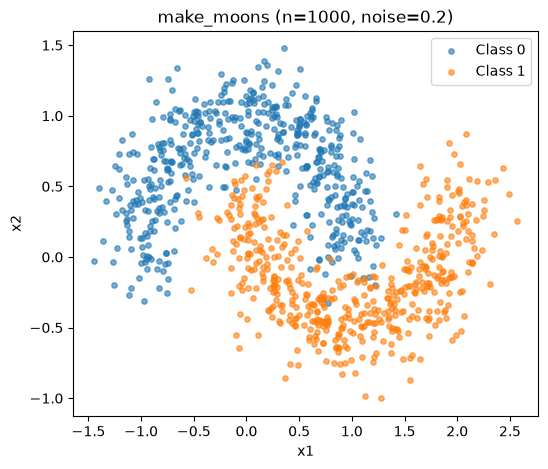

Train (600, 2), Val (200, 2), Test (200, 2)
X_train: torch.Size([600, 2]) torch.float32 | y_train: torch.Size([600, 1]) torch.float32


In [22]:
# ===== Task1 第 1 步：数据生成 + 可视化 + 划分 =====
import numpy as np
import torch
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

# 1) 造数据（固定种子 → 每次跑结果一样）
X, y = make_moons(n_samples=1000, noise=0.2, random_state=SEED)

# 2) 可视化（标签用英文，避开 WSL 中文字体坑）
plt.figure(figsize=(6, 5))
plt.scatter(X[y == 0, 0], X[y == 0, 1], s=15, label="Class 0", alpha=0.6)
plt.scatter(X[y == 1, 0], X[y == 1, 1], s=15, label="Class 1", alpha=0.6)
plt.xlabel("x1"); plt.ylabel("x2"); plt.legend()
plt.title("make_moons (n=1000, noise=0.2)")
plt.show()

# 3) 划分：先 80/20，再 60/20/20（验证集从训练集切 1/4 出来）
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED, stratify=y)
X_train, X_val, y_train, y_val = train_test_split(
    X_train, y_train, test_size=0.25, random_state=SEED, stratify=y_train)
print(f"Train {X_train.shape}, Val {X_val.shape}, Test {X_test.shape}")

# 4) numpy → torch（必须 float32，否则后面算 BCE 会报 expected scalar type Double）
X_train_t = torch.tensor(X_train, dtype=torch.float32)
X_val_t   = torch.tensor(X_val,   dtype=torch.float32)
X_test_t  = torch.tensor(X_test,  dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.float32).reshape(-1, 1)
y_val_t   = torch.tensor(y_val,   dtype=torch.float32).reshape(-1, 1)
y_test_t  = torch.tensor(y_test,  dtype=torch.float32).reshape(-1, 1)
print("X_train:", X_train_t.shape, X_train_t.dtype, "| y_train:", y_train_t.shape, y_train_t.dtype)


In [25]:
import torch.nn as nn

class MLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(2, 16),    # 输入层 → 隐藏层1
            nn.ReLU(),
            nn.Linear(16, 8),    # 隐藏层1 → 隐藏层2
            nn.ReLU(),
            nn.Linear(8, 1),     # 隐藏层2 → 输出
        )

    def forward(self, x):
        return self.net(x)

model = MLP()
print(model)

x_fake = torch.randn(5, 2)
out = model(x_fake)
print(out.shape)
print(out)


MLP(
  (net): Sequential(
    (0): Linear(in_features=2, out_features=16, bias=True)
    (1): ReLU()
    (2): Linear(in_features=16, out_features=8, bias=True)
    (3): ReLU()
    (4): Linear(in_features=8, out_features=1, bias=True)
  )
)
torch.Size([5, 1])
tensor([[-0.3565],
        [-0.3853],
        [-0.3465],
        [-0.3573],
        [-0.3195]], grad_fn=<AddmmBackward0>)


Epoch  100 | train loss 0.6287 | val loss 0.6295 | val acc 0.7650
Epoch  200 | train loss 0.4156 | val loss 0.4290 | val acc 0.8050
Epoch  300 | train loss 0.2875 | val loss 0.3231 | val acc 0.8550
Epoch  400 | train loss 0.2418 | val loss 0.2870 | val acc 0.8650
Epoch  500 | train loss 0.2097 | val loss 0.2552 | val acc 0.8850
Epoch  600 | train loss 0.1786 | val loss 0.2215 | val acc 0.9050
Epoch  700 | train loss 0.1495 | val loss 0.1868 | val acc 0.9150
Epoch  800 | train loss 0.1229 | val loss 0.1560 | val acc 0.9400
Epoch  900 | train loss 0.1033 | val loss 0.1313 | val acc 0.9500
Epoch 1000 | train loss 0.0927 | val loss 0.1180 | val acc 0.9550


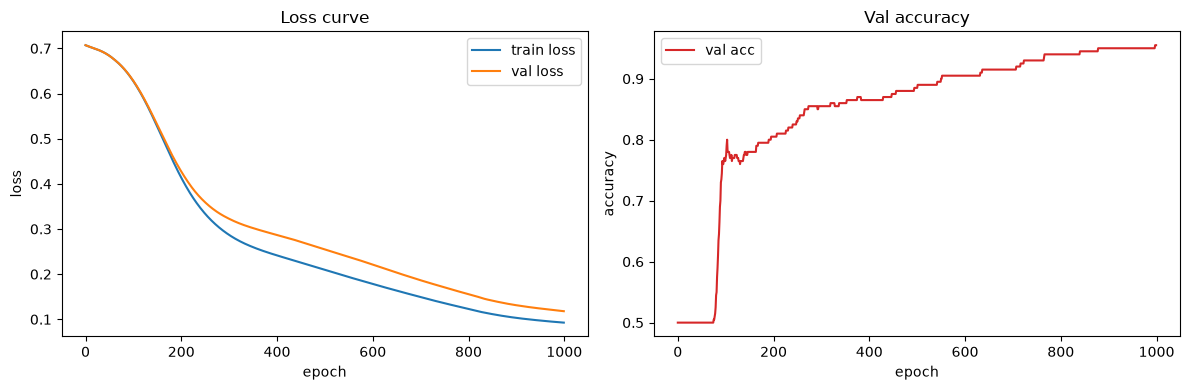

In [26]:
import torch.nn as nn
from sklearn.metrics import accuracy_score

criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

EPOCHS = 1000

# ★ 新增：三个记账本
hist_train_loss = []
hist_val_loss   = []
hist_val_acc    = []

for epoch in range(1, EPOCHS + 1):
    # ===== 训练部分 =====
    model.train()
    logit = model(X_train_t)
    loss = criterion(logit, y_train_t)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    # ===== 验证部分 =====
    model.eval()
    with torch.no_grad():
        val_logit = model(X_val_t)
        val_loss = criterion(val_logit, y_val_t)
        pred = (val_logit > 0).float()
        acc = accuracy_score(y_val_t, pred)

    # ★ 新增：每轮记账
    hist_train_loss.append(loss.item())
    hist_val_loss.append(val_loss.item())
    hist_val_acc.append(acc)

    if epoch % 100 == 0:
        print(f"Epoch {epoch:4d} | train loss {loss.item():.4f} "
              f"| val loss {val_loss.item():.4f} | val acc {acc:.4f}")

# ===== ★ 新增：画曲线 =====
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(hist_train_loss, label="train loss")
axes[0].plot(hist_val_loss, label="val loss")
axes[0].set_xlabel("epoch"); axes[0].set_ylabel("loss")
axes[0].set_title("Loss curve"); axes[0].legend()

axes[1].plot(hist_val_acc, label="val acc", color="tab:red")
axes[1].set_xlabel("epoch"); axes[1].set_ylabel("accuracy")
axes[1].set_title("Val accuracy"); axes[1].legend()

plt.tight_layout()
plt.show()


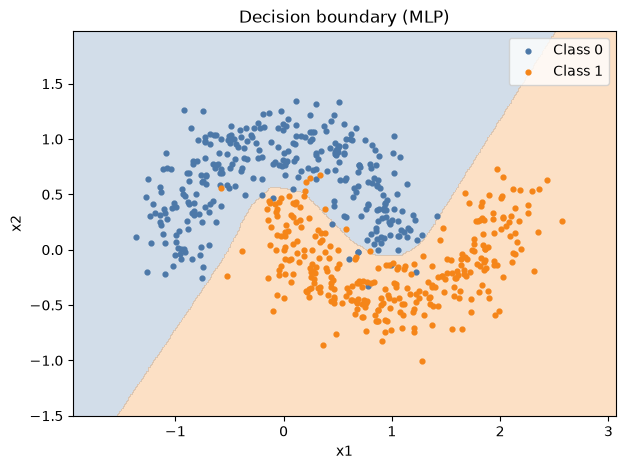

In [27]:
# ===== 第 5 步：决策边界可视化 =====
import numpy as np

# 1) 造一张网格：把整个平面铺满 300x300 个点
x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300),
                     np.linspace(y_min, y_max, 300))

# 2) 把每个网格点喂给模型，看它判成哪类
grid = np.c_[xx.ravel(), yy.ravel()]              # 拼成 (N, 2)
grid_t = torch.tensor(grid, dtype=torch.float32)
with torch.no_grad():                             # 推理，关梯度
    zz = model(grid_t)
zz = (zz > 0).float().numpy().reshape(xx.shape)   # logit>0 → 类1

# 3) 背景染色（模型眼里两类各自的地盘）+ 叠加训练数据点
plt.figure(figsize=(7, 5))
plt.contourf(xx, yy, zz, levels=1, alpha=0.25,
             colors=["#4C78A8", "#F58518"])
plt.scatter(X_train[y_train == 0, 0], X_train[y_train == 0, 1],
            s=12, c="#4C78A8", label="Class 0")
plt.scatter(X_train[y_train == 1, 0], X_train[y_train == 1, 1],
            s=12, c="#F58518", label="Class 1")
plt.xlabel("x1"); plt.ylabel("x2"); plt.legend()
plt.title("Decision boundary (MLP)")
plt.show()


Linear final val acc: 0.8350
MLP    final val acc: 0.9400


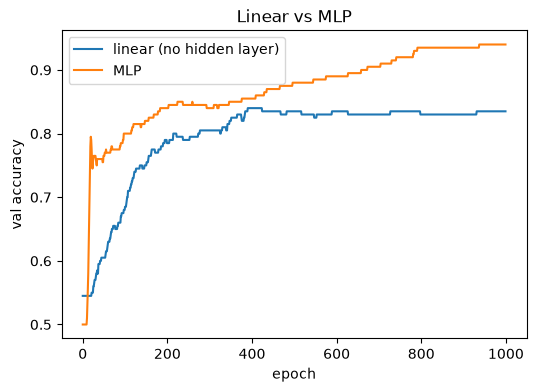

In [28]:
# ===== 第 6 步：对照实验 —— 纯线性模型 vs MLP =====
import torch.nn as nn
from sklearn.metrics import accuracy_score

# 把训练循环封装成函数：以后任何模型丢进来都能训
def train_model(model, EPOCHS=1000, lr=1e-3):
    crit = nn.BCEWithLogitsLoss()
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    hist = {"train_loss": [], "val_loss": [], "val_acc": []}
    for epoch in range(1, EPOCHS + 1):
        # 训练
        model.train()
        loss = crit(model(X_train_t), y_train_t)
        opt.zero_grad()
        loss.backward()
        opt.step()
        # 验证
        model.eval()
        with torch.no_grad():
            val_logit = model(X_val_t)
            val_loss = crit(val_logit, y_val_t)
            acc = accuracy_score(y_val_t, (val_logit > 0).float())
        # 记账
        hist["train_loss"].append(loss.item())
        hist["val_loss"].append(val_loss.item())
        hist["val_acc"].append(acc)
    return hist

# 对照组：没有隐藏层的纯线性模型（结构上等价于逻辑回归，只能画直线）
linear_model = nn.Sequential(nn.Linear(2, 1))

# 实验组：再训一个全新的 MLP（保证两者条件完全一致）
mlp_model = MLP()

hist_linear = train_model(linear_model)
hist_mlp    = train_model(mlp_model)

print(f"Linear final val acc: {hist_linear['val_acc'][-1]:.4f}")
print(f"MLP    final val acc: {hist_mlp['val_acc'][-1]:.4f}")

# val acc 曲线对比图
plt.figure(figsize=(6, 4))
plt.plot(hist_linear["val_acc"], label="linear (no hidden layer)")
plt.plot(hist_mlp["val_acc"], label="MLP")
plt.xlabel("epoch"); plt.ylabel("val accuracy")
plt.title("Linear vs MLP"); plt.legend()
plt.show()


Test accuracy: 0.9850
混淆矩阵（行=真实，列=预测）:
[[98  2]
 [ 1 99]]


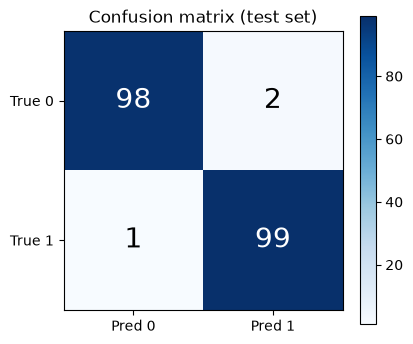

In [29]:
# ===== 第 7 步：混淆矩阵 + 测试集终考 =====
from sklearn.metrics import confusion_matrix

# 注意：用 test 集（高考！只考这一次，前面从没碰过）
model.eval()
with torch.no_grad():
    test_logit = model(X_test_t)
    test_pred = (test_logit > 0).float()

acc_test = accuracy_score(y_test_t, test_pred)
print(f"Test accuracy: {acc_test:.4f}")

cm = confusion_matrix(y_test_t, test_pred)
print("混淆矩阵（行=真实，列=预测）:")
print(cm)

# 画成彩色图更好读
plt.figure(figsize=(4.5, 4))
plt.imshow(cm, cmap="Blues")
for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i, j], ha="center", va="center",
                 fontsize=20,
                 color="white" if cm[i, j] > cm.max() / 2 else "black")
plt.xticks([0, 1], ["Pred 0", "Pred 1"])
plt.yticks([0, 1], ["True 0", "True 1"])
plt.title("Confusion matrix (test set)")
plt.colorbar()
plt.show()


In [30]:
# ===== 第 8 步：模型保存与加载 =====

# 1) 保存：只存参数字典（推荐做法）
torch.save(model.state_dict(), "mlp_moons.pth")
print("saved: mlp_moons.pth")

# 2) 加载：先建一个同结构的新模型，再把参数灌进去
model_loaded = MLP()                                        # 同结构空模型（参数是随机的）
model_loaded.load_state_dict(torch.load("mlp_moons.pth"))   # 灌入学好的参数
model_loaded.eval()                                         # 切到推理模式

# 3) 验证：加载后的模型应该复现一模一样的 test 成绩
with torch.no_grad():
    logit = model_loaded(X_test_t)
    pred = (logit > 0).float()
print("Loaded model test acc:", accuracy_score(y_test_t, pred))


saved: mlp_moons.pth
Loaded model test acc: 0.985
